# Assignment 7: Creating and Fixing Mode Collapse in a GAN

**Name:** Prakruthi BR  
**Course:** BCA  
**Subject:** Generative AI










## Objective

The objective of this assignment is to understand and demonstrate mode collapse
in Generative Adversarial Networks (GANs).

The DCGAN developed in Assignment 4 using the Fashion-MNIST dataset will first
be intentionally made unstable to observe mode collapse.

After observing the problem, the model will be improved using different learning
rates for the Generator and Discriminator.

Finally, the generated outputs before and after the improvement will be compared.

## Introduction

Mode collapse is a common problem in Generative Adversarial Networks (GANs).

In mode collapse, the Generator produces very similar images even when different random noise vectors are provided. Instead of learning different modes of the training dataset, the Generator may repeatedly produce only a small number of patterns.

In this assignment, the working DCGAN from Assignment 4 is intentionally made unstable by:

1. Reducing the capacity of the Generator.
2. Removing Batch Normalization from the Generator.
3. Increasing the learning rate significantly.
4. Training the modified GAN for 15 epochs.

After observing the unstable behavior, the model is improved using different learning rates for the Generator and Discriminator. The generated images and training losses are then compared before and after stabilization.

## Step 1: Import Required Libraries

This cell imports PyTorch and the supporting libraries required for:

- Building the Generator and Discriminator.
- Loading the Fashion-MNIST dataset.
- Training the GAN.
- Saving generated images.
- Plotting the training losses.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image
import torchvision.utils as vutils

import matplotlib.pyplot as plt
import numpy as np
import os

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.11.0+cu130


## Step 2: Define Training Parameters

The parameters below define the image size, batch size, latent vector size, number of epochs, and learning rate.

For Assignment 7, the learning rate is intentionally increased from the stable DCGAN setting used in Assignment 4. A higher learning rate can make GAN training unstable and can contribute to mode collapse.

In [2]:
# Image and training parameters
image_size = 28
channels = 1
batch_size = 128

# Assignment 7 training settings
num_epochs = 15
latent_dim = 100

# Intentionally high learning rate
learning_rate = 0.002

# Adam optimizer parameter
beta1 = 0.5

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Image Size:", image_size)
print("Batch Size:", batch_size)
print("Latent Dimension:", latent_dim)
print("Number of Epochs:", num_epochs)
print("Learning Rate:", learning_rate)

Device: cuda
Image Size: 28
Batch Size: 128
Latent Dimension: 100
Number of Epochs: 15
Learning Rate: 0.002


## Step 3: Load the Fashion-MNIST Dataset

Fashion-MNIST contains grayscale images of clothing items such as shirts, shoes, trousers, bags, and other fashion categories.

The images are converted into tensors and normalized to the range [-1, 1]. This matches the output range of the Generator because the final Generator layer uses the Tanh activation function.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print("Number of training images:", len(train_dataset))
print("Number of batches:", len(dataloader))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.9MB/s]


Number of training images: 60000
Number of batches: 469


## Step 4: Visualize Real Training Images

Before training the GAN, a small batch of real Fashion-MNIST images is displayed.

These images provide a reference for comparing the quality and diversity of the images generated by the GAN.

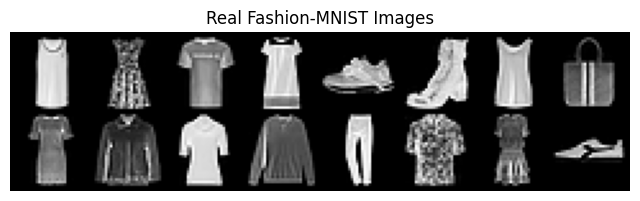

In [4]:
real_batch = next(iter(dataloader))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Real Fashion-MNIST Images")

plt.imshow(
    np.transpose(
        vutils.make_grid(
            real_batch[0][:16],
            padding=2,
            normalize=True
        ).cpu(),
        (1, 2, 0)
    )
)

plt.show()

## Step 5: Intentional Modifications to Induce Mode Collapse

The original DCGAN from Assignment 4 is modified to make the training process unstable.

### Modifications

**1. Reduced Generator Capacity**

The number of feature maps in the Generator is reduced. This limits the Generator's ability to learn diverse Fashion-MNIST patterns.

**2. Batch Normalization Removed from Generator**

Batch Normalization used in the original Generator is removed. This can make the Generator's training less stable.

**3. Higher Learning Rate**

The learning rate is increased to 0.002. This is considerably higher than the stable DCGAN learning rate and can cause unstable competition between the Generator and Discriminator.

These changes are intentionally introduced to demonstrate the effects of unstable GAN training.

## Step 6: Build the Modified Generator

The Generator is intentionally given lower capacity than the original DCGAN.

The Generator starts with a 100-dimensional random latent vector and gradually converts it into a 28 × 28 grayscale image.

Batch Normalization is intentionally removed from this Generator as part of the mode-collapse experiment.

In [5]:
class CollapsedGenerator(nn.Module):
    def __init__(self):
        super(CollapsedGenerator, self).__init__()

        self.model = nn.Sequential(
            # 100 x 1 x 1 -> 32 x 7 x 7
            nn.ConvTranspose2d(
                latent_dim,
                32,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.ReLU(True),

            # 32 x 7 x 7 -> 16 x 14 x 14
            nn.ConvTranspose2d(
                32,
                16,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.ReLU(True),

            # 16 x 14 x 14 -> 1 x 28 x 28
            nn.ConvTranspose2d(
                16,
                channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


generator = CollapsedGenerator().to(device)

print(generator)

CollapsedGenerator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 32, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (5): Tanh()
  )
)


## Step 7: Build the Discriminator

The Discriminator receives a 28 × 28 Fashion-MNIST image and predicts whether the image is real or generated.

It uses convolutional layers to extract image features and a final Sigmoid layer to produce a probability between 0 and 1.

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            # 1 x 28 x 28 -> 64 x 14 x 14
            nn.Conv2d(
                channels,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 14 x 14 -> 128 x 7 x 7
            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),

            # 128 x 7 x 7 -> 1
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


discriminator = Discriminator().to(device)

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=6272, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


## Step 8: Define Loss Function and Optimizers

Binary Cross Entropy (BCE) loss is used because the Discriminator performs a binary classification task:

- Real image → 1
- Generated image → 0

For the intentionally unstable experiment, both the Generator and Discriminator use the high learning rate of 0.002.

In [7]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(beta1, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(beta1, 0.999)
)

print("Loss Function: Binary Cross Entropy")
print("Generator Learning Rate:", learning_rate)
print("Discriminator Learning Rate:", learning_rate)

Loss Function: Binary Cross Entropy
Generator Learning Rate: 0.002
Discriminator Learning Rate: 0.002


## Step 9: Create Fixed Noise

A fixed set of random noise vectors is created before training.

The same noise vectors will be used throughout the experiment to generate images. This allows us to compare how the Generator's output changes during training.

If many different noise vectors produce very similar images, this is an indication of mode collapse.

In [8]:
fixed_noise = torch.randn(
    16,
    latent_dim,
    1,
    1,
    device=device
)

print("Fixed noise shape:", fixed_noise.shape)

Fixed noise shape: torch.Size([16, 100, 1, 1])


## Step 10: Prepare Variables for Training

The following lists store the Generator and Discriminator losses during training.

The generated image grids are also saved at regular intervals so that the evolution of the Generator can be visually examined.

In [9]:
G_losses_collapsed = []
D_losses_collapsed = []

G_epoch_losses_collapsed = []
D_epoch_losses_collapsed = []

os.makedirs("collapsed_output", exist_ok=True)

print("Training variables initialized successfully.")

Training variables initialized successfully.


## Step 11: Train the Intentionally Unstable GAN

The modified GAN is trained for 15 epochs.

The Generator has reduced capacity, Batch Normalization has been removed from the Generator, and a high learning rate is used.

These modifications are intentionally introduced to make GAN training unstable and investigate mode collapse.

In [10]:
for epoch in range(num_epochs):

    running_G_loss = 0.0
    running_D_loss = 0.0

    for i, (real_images, _) in enumerate(dataloader):

        real_images = real_images.to(device)
        current_batch_size = real_images.size(0)

        # -----------------------------
        # Train Discriminator
        # -----------------------------
        discriminator.zero_grad()

        real_labels = torch.ones(
            current_batch_size, 1, device=device
        )

        output_real = discriminator(real_images)

        loss_D_real = criterion(
            output_real,
            real_labels
        )

        noise = torch.randn(
            current_batch_size,
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = generator(noise)

        fake_labels = torch.zeros(
            current_batch_size, 1, device=device
        )

        output_fake = discriminator(
            fake_images.detach()
        )

        loss_D_fake = criterion(
            output_fake,
            fake_labels
        )

        loss_D = loss_D_real + loss_D_fake

        loss_D.backward()
        optimizer_D.step()

        # -----------------------------
        # Train Generator
        # -----------------------------
        generator.zero_grad()

        generator_labels = torch.ones(
            current_batch_size, 1, device=device
        )

        output = discriminator(fake_images)

        loss_G = criterion(
            output,
            generator_labels
        )

        loss_G.backward()
        optimizer_G.step()

        # Store losses
        G_losses_collapsed.append(loss_G.item())
        D_losses_collapsed.append(loss_D.item())

        running_G_loss += loss_G.item()
        running_D_loss += loss_D.item()

    avg_G_loss = running_G_loss / len(dataloader)
    avg_D_loss = running_D_loss / len(dataloader)

    G_epoch_losses_collapsed.append(avg_G_loss)
    D_epoch_losses_collapsed.append(avg_D_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Generator Loss: {avg_G_loss:.4f} "
        f"Discriminator Loss: {avg_D_loss:.4f}"
    )

    # Save generated samples
    if (epoch + 1) % 5 == 0 or epoch == 0:

        with torch.no_grad():
            fake = generator(fixed_noise).detach().cpu()

        save_image(
            fake,
            f"collapsed_output/epoch_{epoch + 1}.png",
            normalize=True,
            nrow=4
        )

Epoch [1/15] Generator Loss: 3.6660 Discriminator Loss: 0.5893
Epoch [2/15] Generator Loss: 2.8192 Discriminator Loss: 0.6123
Epoch [3/15] Generator Loss: 2.4950 Discriminator Loss: 0.7020
Epoch [4/15] Generator Loss: 2.5454 Discriminator Loss: 0.6951
Epoch [5/15] Generator Loss: 2.6067 Discriminator Loss: 0.6433
Epoch [6/15] Generator Loss: 2.6915 Discriminator Loss: 0.6135
Epoch [7/15] Generator Loss: 2.8275 Discriminator Loss: 0.6351
Epoch [8/15] Generator Loss: 2.8865 Discriminator Loss: 0.5873
Epoch [9/15] Generator Loss: 2.9609 Discriminator Loss: 0.5320
Epoch [10/15] Generator Loss: 3.1065 Discriminator Loss: 0.5405
Epoch [11/15] Generator Loss: 3.2313 Discriminator Loss: 0.5639
Epoch [12/15] Generator Loss: 3.3470 Discriminator Loss: 0.4349
Epoch [13/15] Generator Loss: 3.4091 Discriminator Loss: 0.5372
Epoch [14/15] Generator Loss: 3.6218 Discriminator Loss: 0.4871
Epoch [15/15] Generator Loss: 3.5922 Discriminator Loss: 0.4092


## Step 12: Generate Images After Unstable Training

After completing the unstable training, the Generator is used with the fixed noise vectors.

The generated images are stored in `collapsed_images` so that they can be examined and later compared with the stabilized GAN.

If several different noise vectors produce very similar images, this indicates reduced diversity and possible mode collapse.

In [11]:
generator.eval()

with torch.no_grad():
    collapsed_images = generator(fixed_noise).detach().cpu()

generator.train()

print("Unstable GAN images generated successfully.")
print("Image tensor shape:", collapsed_images.shape)

Unstable GAN images generated successfully.
Image tensor shape: torch.Size([16, 1, 28, 28])


## Step 13: Visualize the Unstable Generator Output

The generated images are displayed to inspect whether the Generator has learned diverse Fashion-MNIST patterns.

Repeated or highly similar images indicate reduced diversity and possible mode collapse.

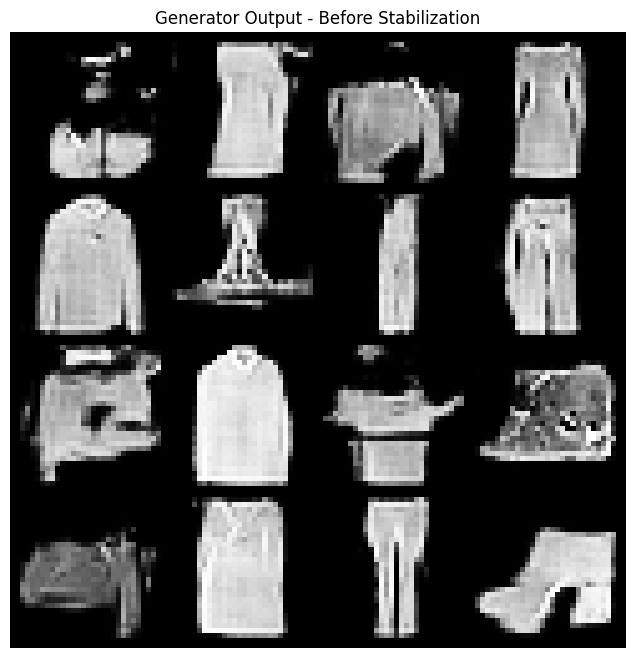

In [12]:
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generator Output - Before Stabilization")

plt.imshow(
    np.transpose(
        vutils.make_grid(
            collapsed_images,
            padding=2,
            normalize=True,
            nrow=4
        ),
        (1, 2, 0)
    )
)

plt.show()

## Step 14: Plot Training Losses Before Stabilization

The Generator and Discriminator losses are plotted to examine the training behavior of the intentionally unstable GAN.

GAN losses may fluctuate during training because the Generator and Discriminator continuously compete with each other.

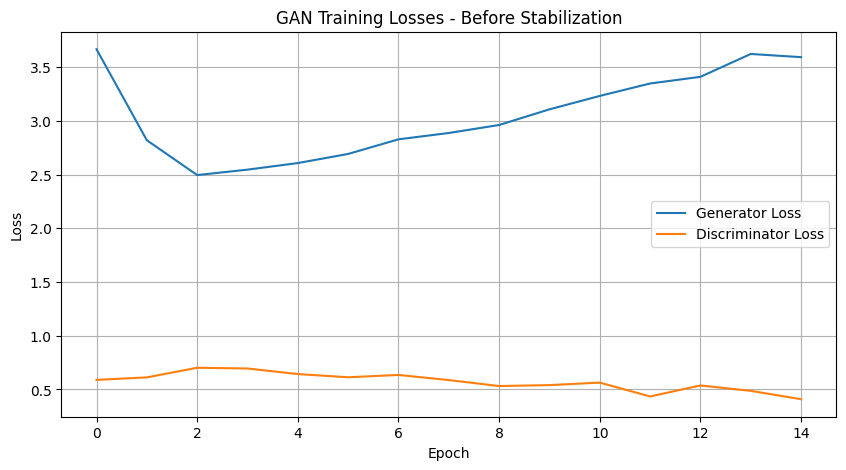

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    G_epoch_losses_collapsed,
    label="Generator Loss"
)

plt.plot(
    D_epoch_losses_collapsed,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses - Before Stabilization")
plt.legend()
plt.grid()

plt.show()

## Step 15: Stabilization Technique — Different Learning Rates

To improve the unstable GAN, different learning rates are assigned to the Generator and Discriminator.

The Generator is given a learning rate of 0.0002, while the Discriminator is given a lower learning rate of 0.0001.

This allows the two networks to learn at different speeds instead of updating equally during unstable training.

The Generator architecture used for the experiment is retained so that the effect of the stabilization technique can be compared with the unstable experiment.

## Step 16: Create Fresh Generator and Discriminator

Fresh models are created before the stabilization experiment.

This is important because the improved experiment should start from newly initialized weights rather than continuing from the unstable model.

In [14]:
generator_fixed = CollapsedGenerator().to(device)
discriminator_fixed = Discriminator().to(device)

print("Fresh Generator created.")
print("Fresh Discriminator created.")

Fresh Generator created.
Fresh Discriminator created.


## Step 17: Define Separate Learning Rates

The Generator and Discriminator now use different learning rates.

- Generator learning rate = 0.0002
- Discriminator learning rate = 0.0001

This difference is used as the stabilization technique for the GAN.

In [15]:
generator_lr_fixed = 0.0002
discriminator_lr_fixed = 0.0001

optimizer_G_fixed = optim.Adam(
    generator_fixed.parameters(),
    lr=generator_lr_fixed,
    betas=(beta1, 0.999)
)

optimizer_D_fixed = optim.Adam(
    discriminator_fixed.parameters(),
    lr=discriminator_lr_fixed,
    betas=(beta1, 0.999)
)

print("Generator Learning Rate:", generator_lr_fixed)
print("Discriminator Learning Rate:", discriminator_lr_fixed)

Generator Learning Rate: 0.0002
Discriminator Learning Rate: 0.0001


## Step 18: Prepare Variables for the Improved Training

New lists are created to store the Generator and Discriminator losses from the stabilized experiment.

The output images are stored separately from the unstable experiment so that the two results can be compared.

In [16]:
G_losses_fixed = []
D_losses_fixed = []

G_epoch_losses_fixed = []
D_epoch_losses_fixed = []

os.makedirs("improved_output", exist_ok=True)

## Step 19: Train the Stabilized GAN

The fresh Generator and Discriminator are trained for the same 15 epochs.

The main difference from the previous experiment is that the Generator and Discriminator now use different learning rates.

This allows us to compare the effect of the stabilization technique while keeping the training duration the same.

In [17]:
for epoch in range(num_epochs):

    running_G_loss = 0.0
    running_D_loss = 0.0

    for i, (real_images, _) in enumerate(dataloader):

        real_images = real_images.to(device)
        current_batch_size = real_images.size(0)

        # --------------------------------------------------
        # Train Discriminator
        # --------------------------------------------------

        discriminator_fixed.zero_grad()

        real_labels = torch.ones(
            current_batch_size,
            1,
            device=device
        )

        output_real = discriminator_fixed(real_images)

        loss_D_real = criterion(
            output_real,
            real_labels
        )

        # Generate fake images
        noise = torch.randn(
            current_batch_size,
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = generator_fixed(noise)

        fake_labels = torch.zeros(
            current_batch_size,
            1,
            device=device
        )

        output_fake = discriminator_fixed(
            fake_images.detach()
        )

        loss_D_fake = criterion(
            output_fake,
            fake_labels
        )

        loss_D = loss_D_real + loss_D_fake

        loss_D.backward()
        optimizer_D_fixed.step()

        # --------------------------------------------------
        # Train Generator
        # --------------------------------------------------

        generator_fixed.zero_grad()

        generator_labels = torch.ones(
            current_batch_size,
            1,
            device=device
        )

        output = discriminator_fixed(fake_images)

        loss_G = criterion(
            output,
            generator_labels
        )

        loss_G.backward()
        optimizer_G_fixed.step()

        # Store losses
        G_losses_fixed.append(loss_G.item())
        D_losses_fixed.append(loss_D.item())

        running_G_loss += loss_G.item()
        running_D_loss += loss_D.item()

    # Average epoch losses
    avg_G_loss = running_G_loss / len(dataloader)
    avg_D_loss = running_D_loss / len(dataloader)

    G_epoch_losses_fixed.append(avg_G_loss)
    D_epoch_losses_fixed.append(avg_D_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Generator Loss: {avg_G_loss:.4f} "
        f"Discriminator Loss: {avg_D_loss:.4f}"
    )

    # Save generated images
    if (epoch + 1) % 5 == 0 or epoch == 0:

        with torch.no_grad():
            fake = generator_fixed(
                fixed_noise
            ).detach().cpu()

        save_image(
            fake,
            f"improved_output/epoch_{epoch + 1}.png",
            normalize=True,
            nrow=4
        )

Epoch [1/15] Generator Loss: 2.6603 Discriminator Loss: 0.2041
Epoch [2/15] Generator Loss: 3.7616 Discriminator Loss: 0.0840
Epoch [3/15] Generator Loss: 4.0192 Discriminator Loss: 0.1035
Epoch [4/15] Generator Loss: 4.0381 Discriminator Loss: 0.0555
Epoch [5/15] Generator Loss: 3.9966 Discriminator Loss: 0.0988
Epoch [6/15] Generator Loss: 3.9822 Discriminator Loss: 0.1077
Epoch [7/15] Generator Loss: 4.5492 Discriminator Loss: 0.0428
Epoch [8/15] Generator Loss: 4.4574 Discriminator Loss: 0.1100
Epoch [9/15] Generator Loss: 4.2832 Discriminator Loss: 0.1275
Epoch [10/15] Generator Loss: 3.8086 Discriminator Loss: 0.1197
Epoch [11/15] Generator Loss: 3.6705 Discriminator Loss: 0.1411
Epoch [12/15] Generator Loss: 3.5035 Discriminator Loss: 0.1429
Epoch [13/15] Generator Loss: 3.4023 Discriminator Loss: 0.1601
Epoch [14/15] Generator Loss: 3.3440 Discriminator Loss: 0.1618
Epoch [15/15] Generator Loss: 3.3321 Discriminator Loss: 0.1735


## Step 20: Visualize the Stabilized Generator Output

The same fixed noise vectors used in the first experiment are used again.

This makes the visual comparison between the unstable and stabilized experiments more meaningful.

The generated images should be examined for:

- Greater diversity.
- Fewer repeated images.
- Better representation of Fashion-MNIST shapes.
- Improved visual quality.

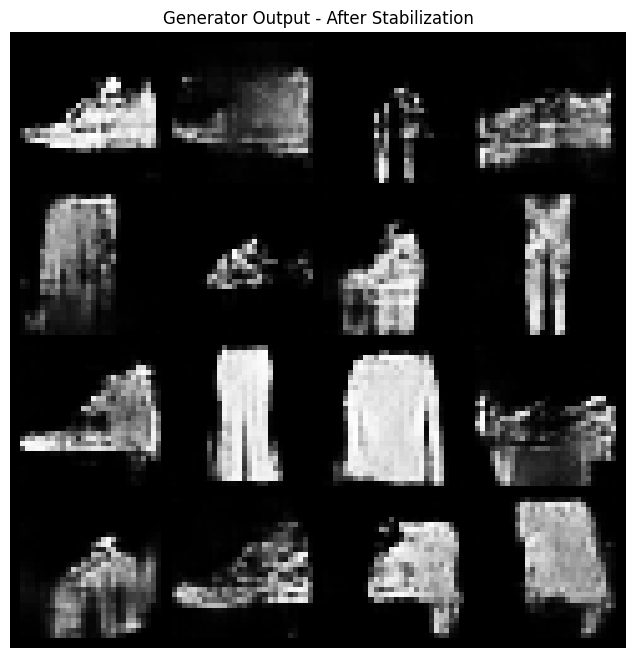

In [18]:
generator_fixed.eval()

with torch.no_grad():
    improved_images = generator_fixed(
        fixed_noise
    ).detach().cpu()

generator_fixed.train()

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generator Output - After Stabilization")

plt.imshow(
    np.transpose(
        vutils.make_grid(
            improved_images,
            padding=2,
            normalize=True,
            nrow=4
        ),
        (1, 2, 0)
    )
)

plt.show()

## Step 21: Plot Training Losses After Stabilization

The Generator and Discriminator losses from the stabilized experiment are plotted.

This graph is compared with the loss graph from the unstable experiment to understand whether the different learning rates resulted in more controlled training.

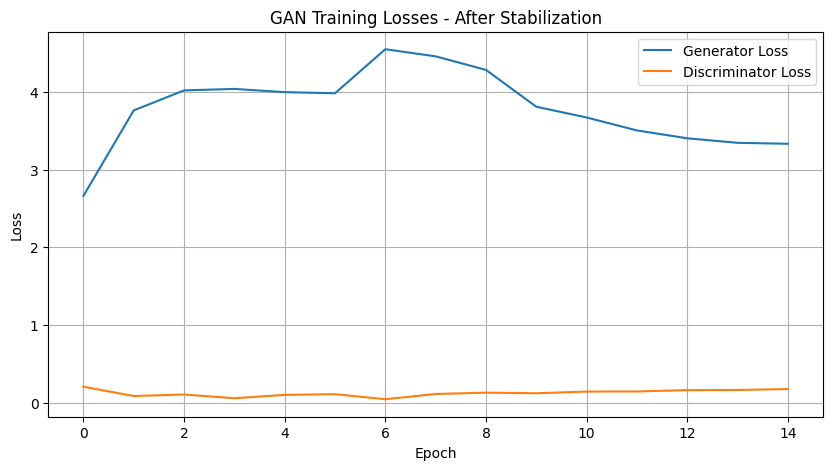

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    G_epoch_losses_fixed,
    label="Generator Loss"
)

plt.plot(
    D_epoch_losses_fixed,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses - After Stabilization")
plt.legend()
plt.grid()

plt.show()

## Step 22: Before and After Stabilization Comparison

The outputs from the unstable and stabilized GANs are compared using the same fixed noise vectors.

This allows us to visually evaluate whether the stabilization technique improves the diversity of generated images.

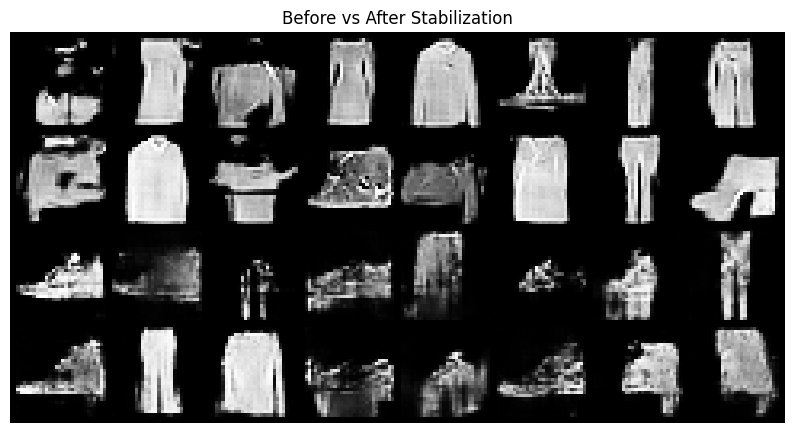

In [20]:
comparison = torch.cat(
    [collapsed_images, improved_images],
    dim=0
)

plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Before vs After Stabilization")

grid = vutils.make_grid(
    comparison,
    nrow=8,
    padding=2,
    normalize=True
)

plt.imshow(
    np.transpose(
        grid,
        (1, 2, 0)
    )
)

plt.show()

## Step 23: Display Separate Outputs for Clear Comparison

The unstable and stabilized results are displayed separately again so that the diversity of the generated images can be inspected carefully.

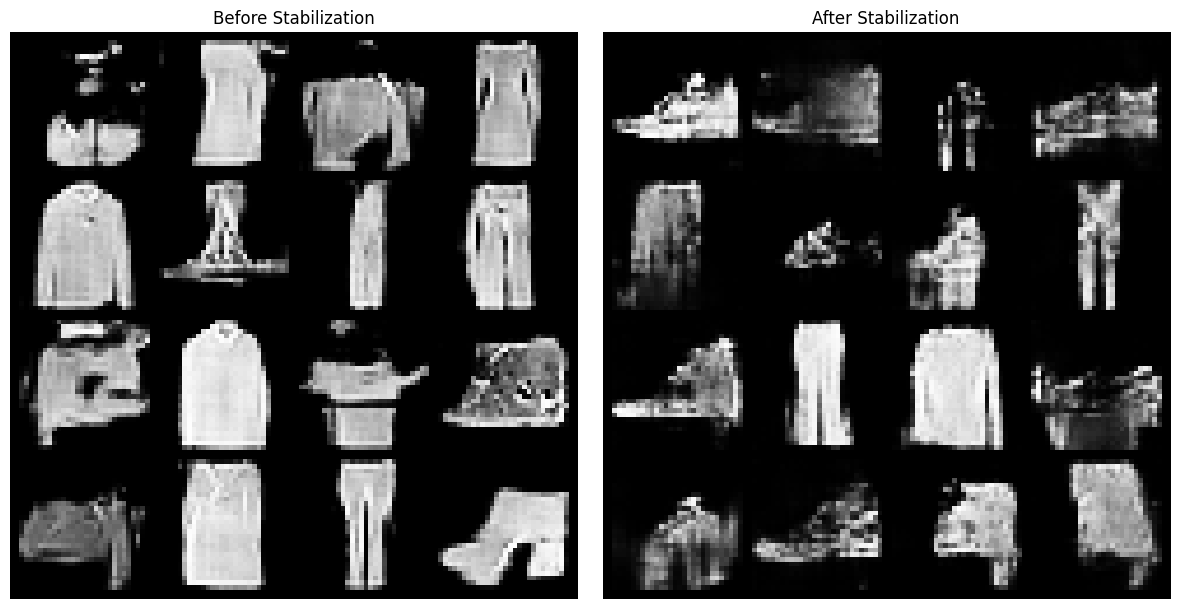

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Before
axes[0].imshow(
    np.transpose(
        vutils.make_grid(
            collapsed_images,
            nrow=4,
            padding=2,
            normalize=True
        ),
        (1, 2, 0)
    )
)

axes[0].set_title("Before Stabilization")
axes[0].axis("off")

# After
axes[1].imshow(
    np.transpose(
        vutils.make_grid(
            improved_images,
            nrow=4,
            padding=2,
            normalize=True
        ),
        (1, 2, 0)
    )
)

axes[1].set_title("After Stabilization")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Step 24: Experimental Comparison

| Aspect | Before Stabilization | After Stabilization |
|---|---|---|
| Generator Capacity | Reduced | Reduced |
| Generator Batch Normalization | Removed | Removed |
| Generator Learning Rate | 0.002 | 0.0002 |
| Discriminator Learning Rate | 0.002 | 0.0001 |
| Epochs | 15 | 15 |
| Training Behavior | Intentionally unstable | More controlled |
| Output Diversity | Inspect generated images | Inspect generated images |
| Mode Collapse | Check for repeated patterns | Check whether diversity improves |

## Step 25: Assignment Questions and Answers

### 1. What is mode collapse in GANs?

Mode collapse is a failure mode in GAN training where the Generator produces very similar or repeated outputs for different input noise vectors. Instead of learning the different patterns present in the dataset, the Generator learns only a limited number of patterns.

### 2. Why can a high learning rate cause GAN instability?

A high learning rate can cause the Generator and Discriminator to update too aggressively. Since GAN training involves two competing networks, large updates can make the competition unstable and prevent the networks from reaching a balanced state.

### 3. How does reducing Generator capacity contribute to mode collapse?

A Generator with lower capacity has fewer parameters and may have difficulty representing the different modes of the training dataset. As a result, it may learn a limited set of patterns and repeatedly generate similar outputs.

### 4. How can different learning rates help stabilize GAN training?

Using different learning rates allows the Generator and Discriminator to learn at different speeds. This can reduce an imbalance between the two networks and can make the adversarial training process more controlled.

## Final Analysis

In this experiment, a working DCGAN was intentionally modified to demonstrate the problem of mode collapse.

The Generator capacity was reduced, Batch Normalization was removed from the Generator, and the learning rate was increased significantly. These changes were designed to make GAN training unstable and encourage reduced diversity in generated images.

After the unstable experiment, the model was trained again using different learning rates for the Generator and Discriminator. The Generator used a learning rate of 0.0002, while the Discriminator used 0.0001.

The generated images before and after stabilization were compared using the same fixed noise vectors. The loss curves were also analyzed to understand the change in training behavior.

The experiment demonstrates that GAN training is sensitive to model capacity, normalization, learning rates, and the balance between the Generator and Discriminator.

## Conclusion

Mode collapse is an important challenge in GAN training because it reduces the diversity of generated samples.

In this assignment, mode-collapse behavior was intentionally investigated by reducing Generator capacity, removing Batch Normalization from the Generator, and increasing the learning rate.

A stabilization experiment using different learning rates for the Generator and Discriminator was then performed.

The before-and-after generated images and loss curves provide a visual and quantitative way to study the effect of stabilization on GAN training.

Overall, the experiment shows the importance of maintaining a suitable balance between the Generator and Discriminator during GAN training.